In [10]:
import torch
from tianshou.data import Collector, VectorReplayBuffer
from tianshou.env import DummyVectorEnv
from tianshou.policy import DQNPolicy
from tianshou.trainer import OffpolicyTrainer
from dengue_envs.envs.dengue_diagnostics import DengueDiagnosticsEnv
from dengue_wrapper import DengueWrapper, CaseByCaseWrapper
from fcn_network import DengueNet

In [11]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
LR = 1e-4
GAMMA = 0.99
BUFFER_SIZE = 1000
BATCH_SIZE = 64
N_STEP = 3
TARGET_UPDATE_FREQ = 500
EPS_TRAIN_START = 1.0
EPS_TRAIN_FINAL = 0.05
EPS_TRAIN_DECAY = 10000
EPS_TEST = 0.01

NUM_ENVS = 4
NUM_TEST_ENVS = 4
EPOCH = 5
STEP_PER_EPOCH = 1000
STEP_PER_COLLECT = 10
UPDATE_PER_STEP = 0.1

In [12]:
def make_env():
    """Função factory para criar o ambiente com wrappers."""
    env = DengueDiagnosticsEnv(epilength=60, size=400)
    env = DengueWrapper(env)
    env = CaseByCaseWrapper(env)
    return env

In [13]:
import os
from tianshou.utils import TensorBoardLogger
from torch.utils.tensorboard import SummaryWriter
# Define o caminho dos logs
LOG_DIR = "logs/dqn"
os.makedirs(LOG_DIR, exist_ok=True)
writer = SummaryWriter(LOG_DIR)
logger = TensorBoardLogger(writer)

ImportError: cannot import name 'TensorBoardLogger' from 'tianshou.utils' (C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\utils\__init__.py)

Iniciando treinamento na cpu...


Epoch #1:   0%|          | 0/1000 [00:00<?, ?it/s]C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=10 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(


Epoch #1:   1%|1         | 12/1000 [00:11<15:56,  1.03it/s, env_step=12, gradient_step=1, len=0, n/ep=0, n/st=12, rew=0.00]C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=10 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(
Epoch #1:  16%|#5        | 156/1000 [00:44<03:17,  4.28it/s, env_step=156, gradient_step=13, len=0, n/ep=0, n/st=12, rew=0.00]

Epoch #1:  17%|#6        | 168/1000 [00:50<04:23,  3.16it/s, env_step=168, gradient_step=14, len=0, n/ep=0, n/st=12, rew=0.00]C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=10 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(
Epoch #1:  37%|###7      | 372/1000 [01:36<02:11,  4.79it/s, env_step=372, gradient_step=31, len=0, n/ep=0, n/st=12, rew=0.00]

Epoch #1:  38%|###8      | 384/1000 [01:45<03:41,  2.78it/s, env_step=384, gradient_step=32, len=0, n/ep=0, n/st=12, rew=0.00]C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=10 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(
Epoch #1:  60%|######    | 600/1000 [02:43<01:47,  3.72it/s, env_step=600, gradient_step=50, len=0, n/ep=0, n/st=12, rew=0.00]

...

Epoch #1:  79%|#######9  | 792/1000 [03:41<01:23,  2.50it/s, env_step=792, gradient_step=66, len=0, n/ep=0, n/st=12, rew=0.00]C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=10 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(
Epoch #1:  90%|######### | 900/1000 [04:01<00:18,  5.39it/s, env_step=900, gradient_step=75, len=0, n/ep=0, n/st=12, rew=0.00]

Epoch #1:  91%|#########1| 912/1000 [04:08<00:26,  3.35it/s, env_step=912, gradient_step=76, len=0, n/ep=0, n/st=12, rew=0.00]C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=10 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(
Epoch #1:  96%|#########6| 960/1000 [04:19<00:10,  3.81it/s, env_step=960, gradient_step=80, len=0, n/ep=0, n/st=12, rew=0.00]

Epoch #1:  97%|#########7| 972/1000 [04:27<00:10,  2.71it/s, env_step=972, gradient_step=81, len=0, n/ep=0, n/st=12, rew=0.00]C:\Users\segun\AppData\Local\pypoetry\Cache\virtualenvs\dengue-diagnostics-env-Ra5buD89-py3.12\Lib\site-packages\tianshou\data\collector.py:323: UserWarning: n_step=10 is not a multiple of (self.env_num=4), which may cause extra transitions being collected into the buffer.
  warnings.warn(
Epoch #1: 100%|#########9| 996/1000 [04:32<00:01,  3.36it/s, env_step=996, gradient_step=83, len=0, n/ep=0, n/st=12, rew=0.00]

Epoch #1: 1008it [04:40,  3.59it/s, env_step=1008, gradient_step=84, len=0, n/ep=0, n/st=12, rew=0.00]                        


Epoch #1: test_reward: 1208.750000 ± 3.269174, best_reward: 1758.875000 ± 4.890999 in #0

--- Resultado do Treinamento ---
InfoStats(gradient_step=84, best_reward=1758.875, best_reward_std=4.8909993866284625, train_step=1008, train_episode=np.int64(0), test_step=2944, test_episode=np.int64(8), timing=TimingStats(total_time=1442.010207414627, train_time=280.7057490348816, train_time_collect=58.86753177642822, train_time_update=216.81968212127686, test_time=1161.3044583797455, update_speed=3.5909488974333117))
Política salva em dqn_dengue_policy.pth


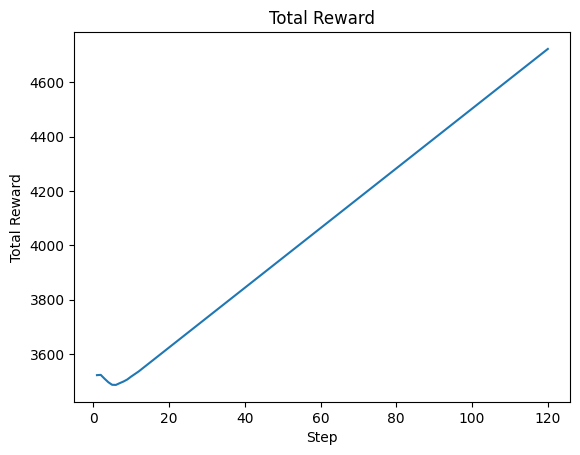

In [14]:
if True:
    train_envs = DummyVectorEnv([make_env for _ in range(NUM_ENVS)])
    test_envs = DummyVectorEnv([make_env for _ in range(NUM_TEST_ENVS)])

    env = make_env()
    map_shape = env.observation_space.spaces["map"].shape
    action_shape = env.action_space.n

    net = DengueNet(map_shape, action_shape, device=DEVICE).to(DEVICE)
    optim = torch.optim.Adam(net.parameters(), lr=LR)

    policy = DQNPolicy(
        model=net,
        optim=optim,
        discount_factor=GAMMA,
        estimation_step=N_STEP,
        target_update_freq=TARGET_UPDATE_FREQ,
        action_space=env.action_space
    )

    buffer = VectorReplayBuffer(
        total_size=BUFFER_SIZE,
        buffer_num=NUM_ENVS,
        ignore_obs_next=True
    )

    train_collector = Collector(
        policy, train_envs, buffer, exploration_noise=True
    )
    test_collector = Collector(policy, test_envs)


    def train_fn(epoch, env_step):
        if env_step <= EPS_TRAIN_DECAY:
            eps = EPS_TRAIN_START - env_step / EPS_TRAIN_DECAY * \
                  (EPS_TRAIN_START - EPS_TRAIN_FINAL)
        else:
            eps = EPS_TRAIN_FINAL
        policy.set_eps(eps)


    def test_fn(epoch, env_step):
        policy.set_eps(EPS_TEST)

    trainer = OffpolicyTrainer(
        policy=policy,
        train_collector=train_collector,
        test_collector=test_collector,
        max_epoch=EPOCH,
        step_per_epoch=STEP_PER_EPOCH,
        step_per_collect=STEP_PER_COLLECT,
        update_per_step=UPDATE_PER_STEP,
        episode_per_test=NUM_TEST_ENVS,
        batch_size=BATCH_SIZE,
        train_fn=train_fn,
        test_fn=test_fn,
        stop_fn=lambda mean_rewards: mean_rewards >= 1000
    )

    print(f"Iniciando treinamento na {DEVICE}...")
    result = trainer.run()
    print("\n--- Resultado do Treinamento ---")
    print(result)

    torch.save(policy.state_dict(), "dqn_dengue_policy.pth")
    print("Política salva em dqn_dengue_policy.pth")